# Carbon Paradox

## Worth its weight in carbon?

### An Analysis of Net-Positive Machine Learning in Grid Carbon Forecasting

## Setup

In [47]:
import pandas as pd
import os
import sys
from pathlib import Path

ROOT = Path(r"C:\Users\erinb\OneDrive\Documents\Georgetown\DSAN 5550\carbon-paradox")
os.chdir(ROOT)
sys.path.append(str(ROOT))

DATA_DIR = ROOT / "data" / "processed"
OUT_DIR = ROOT / "out"

from src.visualization import plot_codecarbon, plot_model_comparison, plot_predictions

## Processed Data

In [48]:
generation = pd.read_csv(DATA_DIR / "generation_by_fuel_hourly.csv")
emissions = pd.read_csv(DATA_DIR / "emissions_factors_by_fuel.csv")
regions = pd.read_csv(DATA_DIR / "egrid_region_reference.csv")
subregions = pd.read_csv(DATA_DIR / "egrid_subregions.csv")
edges = pd.read_csv(DATA_DIR / "grid_edges.csv")

In [49]:
generation.head()

,timestamp,region,region_name,fuel_type,generation_mwh
0,2024-01-01T00,PJM,"PJM Interconnection, LLC",Coal,14814
1,2024-01-01T00,PJM,"PJM Interconnection, LLC",Natural Gas,40727
2,2024-01-01T00,PJM,"PJM Interconnection, LLC",Nuclear,33462
3,2024-01-01T00,PJM,"PJM Interconnection, LLC",Petroleum,210
4,2024-01-01T00,PJM,"PJM Interconnection, LLC",Other,1008


In [50]:
emissions

,fuel_type,kgco2e_per_mwh
0,Coal,1000.0
1,Natural Gas,450.0
2,Petroleum,780.0
3,Other Gases,600.0
4,Nuclear,12.0
5,Hydro,24.0
6,Wind,11.0
7,Solar,45.0
8,Biomass,230.0
9,Geothermal,38.0


In [51]:
regions.head()

,region_code,region_name,annual_co2_rate
0,SUBRGN,SRNAME,SRCO2AN
1,AKGD,ASCC Alaska Grid,2292658.457
2,AKMS,ASCC Miscellaneous,411710.53
3,AZNM,WECC Southwest,61769179.175
4,CAMX,WECC California,47342486.547


In [52]:
subregions.head()

,region_code,region_name
0,AKGD,AKGD
1,AKMS,AKMS
2,AZNM,AZNM
3,CAMX,CAMX
4,ERCT,ERCT


In [53]:
edges.head()

,source_region,target_region,edge_type
0,AKGD,AKMS,adjacent_subregion
1,AZNM,CAMX,adjacent_subregion
2,AZNM,ERCT,adjacent_subregion
3,AZNM,MROW,adjacent_subregion
4,AZNM,NWPP,adjacent_subregion


## Preprocessed Model Data

In [54]:
model_data = pd.read_csv(DATA_DIR / "model_ready_data.csv")
model_data.head()

,timestamp,region,region_name,total_generation_mwh,total_co2_kg,carbon_intensity_kg_per_mwh,hour,day_of_week,month,lag_1,lag_24,target_carbon_intensity_24h
0,2024-01-02 00:00:00,CISO,California Independent System Operator,19732,4149260.0,210.280762,0,1,1,236.791290,266.008324,228.984253
1,2024-01-02 01:00:00,CISO,California Independent System Operator,18429,3881927.0,210.642303,1,1,1,210.280762,284.906921,236.813868
2,2024-01-02 02:00:00,CISO,California Independent System Operator,17709,4766326.0,269.147100,2,1,1,210.642303,294.015846,272.561522
3,2024-01-02 03:00:00,CISO,California Independent System Operator,19440,5384713.0,276.991409,3,1,1,269.147100,276.442321,259.718885
4,2024-01-02 04:00:00,CISO,California Independent System Operator,19920,5552338.0,278.731827,4,1,1,276.991409,284.719560,261.548556


## Baseline Model

In [55]:
baseline_metrics = pd.read_csv(OUT_DIR / "baseline_metrics.csv")
baseline_predictions = pd.read_csv(OUT_DIR / "baseline_predictions.csv")
baseline_codecarbon = pd.read_csv(OUT_DIR / "baseline_codecarbon.csv")

In [56]:
baseline_metrics

,metric,value
0,mae,25.778723
1,rmse,31.548574


In [57]:
baseline_predictions.head()

,timestamp,region,region_name,total_generation_mwh,total_co2_kg,carbon_intensity_kg_per_mwh,hour,day_of_week,month,lag_1,lag_24,target_carbon_intensity_24h,actual,prediction
0,2024-01-06 00:00:00,CISO,California Independent System Operator,21359,4588227.0,214.814692,0,5,1,235.065509,201.555270,183.162556,183.162556,210.61732
1,2024-01-06 00:00:00,NYIS,New York Independent System Operator,16855,4010068.0,237.915633,0,5,1,240.272950,249.343827,244.926191,244.926191,245.02426
2,2024-01-06 00:00:00,PJM,"PJM Interconnection, LLC",108956,42052608.0,385.959543,0,5,1,388.546032,387.248834,390.507438,390.507438,390.26514
3,2024-01-06 01:00:00,CISO,California Independent System Operator,20958,4326530.0,206.438114,1,5,1,214.814692,219.356776,201.651408,201.651408,217.48206
4,2024-01-06 01:00:00,NYIS,New York Independent System Operator,16391,3957979.0,241.472698,1,5,1,237.915633,249.460741,246.648217,246.648217,244.44296


In [58]:
baseline_codecarbon

,timestamp,project_name,run_id,experiment_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,latitude,ram_total_size,tracking_mode,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,on_cloud,pue,wue
0,2026-04-01T16:41:51,carbon_paradox_baseline,3b0806e1-d9a4-4e5c-a8a9-33a2800a32d7,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,1.623680,0.000001,7.584788e-07,8.093020,0.0,10.0,...,38.8957,15.406086,machine,0,0,0,0,N,1.0,0.0
1,2026-04-01T17:13:06,carbon_paradox_baseline,fad24a75-2c72-494c-b413-1ce109e98345,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,1.640564,0.000001,7.333663e-07,7.415647,0.0,10.0,...,38.8957,15.406086,machine,0,0,0,0,N,1.0,0.0


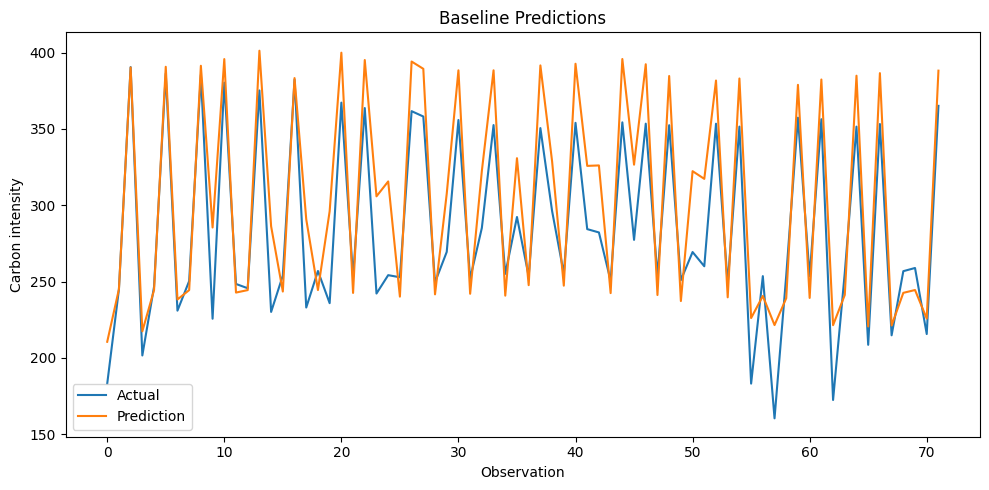

In [59]:
plot_predictions(OUT_DIR / "baseline_predictions.csv", "Baseline Predictions")

## GNN Model

In [60]:
gnn_metrics = pd.read_csv(OUT_DIR / "gnn_metrics.csv")
gnn_predictions = pd.read_csv(OUT_DIR / "gnn_predictions.csv")
gnn_codecarbon = pd.read_csv(OUT_DIR / "gnn_codecarbon.csv")

In [61]:
gnn_metrics

,metric,value
0,mae,61.294975
1,rmse,66.018142


In [62]:
gnn_predictions.head()

,timestamp,region,actual,prediction
0,2024-01-06 00:00:00,CISO,183.16257,286.80264
1,2024-01-06 00:00:00,NYIS,244.92620,286.80264
2,2024-01-06 00:00:00,PJM,390.50745,286.80264
3,2024-01-06 01:00:00,CISO,201.65143,288.54926
4,2024-01-06 01:00:00,NYIS,246.64822,288.54926


In [63]:
gnn_codecarbon

,timestamp,project_name,run_id,experiment_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,latitude,ram_total_size,tracking_mode,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,on_cloud,pue,wue
0,2026-04-01T16:48:36,carbon_paradox_gnn,e6c5dd72-734a-4939-86b4-efe163532733,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,59.274861,0.000058,9.760556e-07,6.641303,0.0,10.0,...,38.8957,15.406086,machine,1.252632,0,80.626316,12.421269,N,1.0,0.0
1,2026-04-01T17:03:26,carbon_paradox_gnn,590cc0f1-c576-4517-86b7-aaee8d7a6c00,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,61.595581,0.000069,1.124824e-06,5.390250,0.0,10.0,...,38.8957,15.406086,machine,0.000000,0,84.425424,13.006537,N,1.0,0.0
2,2026-04-01T17:11:54,carbon_paradox_gnn,e904c870-092b-477d-aa80-a966e942e620,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,50.615378,0.000049,9.668787e-07,6.499277,0.0,10.0,...,38.8957,15.406086,machine,0.000000,0,80.689583,12.430617,N,1.0,0.0
3,2026-04-01T17:32:49,carbon_paradox_gnn,683088a6-7e9d-4d41-9db4-927bd9191402,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,52.780583,0.000052,9.906135e-07,6.957521,0.0,10.0,...,38.8957,15.406086,machine,0.000000,0,82.242000,12.669152,N,1.0,0.0
4,2026-04-01T17:35:21,carbon_paradox_gnn,32303a94-7b66-4923-9bdd-eeeab7a8e702,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,47.665535,0.000047,9.784321e-07,6.560730,0.0,10.0,...,38.8957,15.406086,machine,2.222222,0,83.053333,12.794554,N,1.0,0.0


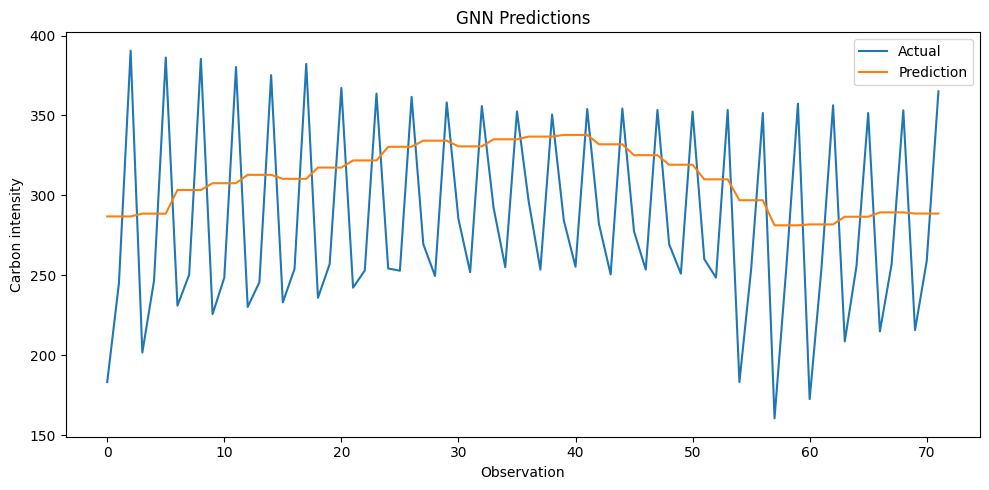

In [64]:
plot_predictions(OUT_DIR / "gnn_predictions.csv", "GNN Predictions")

## Evaluation

In [65]:
comparison = pd.read_csv(OUT_DIR / "model_comparison.csv")
simulation = pd.read_csv(OUT_DIR / "charging_simulation.csv")
break_even = pd.read_csv(OUT_DIR / "break_even_analysis.csv")

In [66]:
comparison

,metric,value_baseline,value_gnn
0,mae,25.778723,61.294975
1,rmse,31.548574,66.018142


In [67]:
simulation.head()

,model,region,date,random_actual_carbon_intensity,optimized_actual_carbon_intensity,emissions_saved_kg
0,baseline,CISO,2024-01-06,237.874164,183.162556,0.547116
1,baseline,NYIS,2024-01-06,252.279992,250.978404,0.013016
2,baseline,PJM,2024-01-06,363.014423,357.367954,0.056465
3,gnn,CISO,2024-01-06,237.874174,160.473400,0.774008
4,gnn,NYIS,2024-01-06,252.279999,254.112240,-0.018322


In [68]:
break_even

,model,training_emissions_kg,average_savings_per_session_kg,sessions_to_break_even
0,baseline,0.000002,0.205532,0.000012
1,gnn,0.000275,0.270717,0.001016


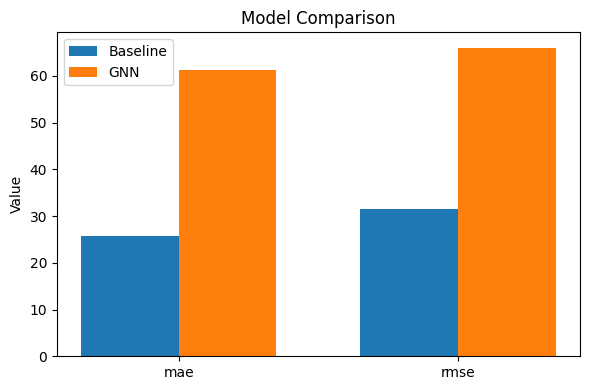

In [69]:
plot_model_comparison()

In [70]:
codecarbon_summary = pd.DataFrame({
    "model": ["baseline", "gnn"],
    "duration_seconds": [
        baseline_codecarbon["duration"].iloc[0],
        gnn_codecarbon["duration"].iloc[0],
    ],
    "energy_consumed_kwh": [
        baseline_codecarbon["energy_consumed"].iloc[0],
        gnn_codecarbon["energy_consumed"].iloc[0],
    ],
    "emissions_kg_co2eq": [
        baseline_codecarbon["emissions"].iloc[0],
        gnn_codecarbon["emissions"].iloc[0],
    ],
    "cpu_model": [
        baseline_codecarbon["cpu_model"].iloc[0],
        gnn_codecarbon["cpu_model"].iloc[0],
    ],
    "region": [
        baseline_codecarbon["region"].iloc[0],
        gnn_codecarbon["region"].iloc[0],
    ],
})

codecarbon_summary

,model,duration_seconds,energy_consumed_kwh,emissions_kg_co2eq,cpu_model,region
0,baseline,1.623680,0.000006,0.000001,AMD Ryzen 7 5800H with Radeon Graphics,district of columbia
1,gnn,59.274861,0.000265,0.000058,AMD Ryzen 7 5800H with Radeon Graphics,district of columbia


In [71]:
tradeoff = comparison.copy()
tradeoff["model"] = tradeoff["metric"]
tradeoff = tradeoff.drop(columns=["metric"])

tradeoff = pd.DataFrame({
    "model": ["baseline", "gnn"],
    "mae": [
        comparison.loc[comparison["metric"] == "mae", "value_baseline"].iloc[0],
        comparison.loc[comparison["metric"] == "mae", "value_gnn"].iloc[0],
    ],
    "rmse": [
        comparison.loc[comparison["metric"] == "rmse", "value_baseline"].iloc[0],
        comparison.loc[comparison["metric"] == "rmse", "value_gnn"].iloc[0],
    ],
    "emissions_kg_co2eq": [
        codecarbon_summary.loc[codecarbon_summary["model"] == "baseline", "emissions_kg_co2eq"].iloc[0],
        codecarbon_summary.loc[codecarbon_summary["model"] == "gnn", "emissions_kg_co2eq"].iloc[0],
    ],
    "energy_consumed_kwh": [
        codecarbon_summary.loc[codecarbon_summary["model"] == "baseline", "energy_consumed_kwh"].iloc[0],
        codecarbon_summary.loc[codecarbon_summary["model"] == "gnn", "energy_consumed_kwh"].iloc[0],
    ],
    "sessions_to_break_even": [
        break_even.loc[break_even["model"] == "baseline", "sessions_to_break_even"].iloc[0],
        break_even.loc[break_even["model"] == "gnn", "sessions_to_break_even"].iloc[0],
    ],
})

tradeoff


,model,mae,rmse,emissions_kg_co2eq,energy_consumed_kwh,sessions_to_break_even
0,baseline,25.778723,31.548574,0.000001,0.000006,0.000012
1,gnn,61.294975,66.018142,0.000058,0.000265,0.001016


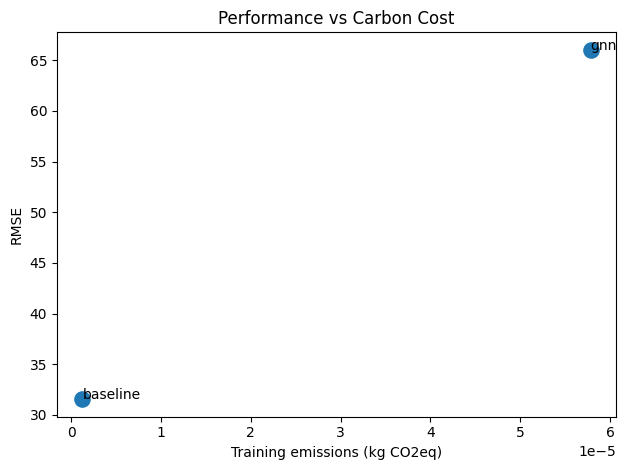

In [72]:
import matplotlib.pyplot as plt

plt.scatter(tradeoff["emissions_kg_co2eq"], tradeoff["rmse"], s=120)

for _, row in tradeoff.iterrows():
    plt.text(row["emissions_kg_co2eq"], row["rmse"], row["model"])

plt.xlabel("Training emissions (kg CO2eq)")
plt.ylabel("RMSE")
plt.title("Performance vs Carbon Cost")
plt.tight_layout()
plt.show()
